In [1]:
import scipy as sp
from scipy.integrate import quad
from numpy import exp, sqrt, pi, cos, sin, linspace, zeros, log, log10
import matplotlib.pyplot as plt
from utils import e_r_cpa
from utils import hl2, hl2prime, hl1, hl1prime, e_r_cpa, h_r_cpa, e_r_cpa_numerator, h_r_cpa_numerator, graphene_conductivity
from scipy.special import jv, hankel2, hankel1, yv, jvp, yvp, spherical_jn, spherical_yn, factorial2
from utils import hbar, c, alpha # Plank's constant in eV*s, speed of light in nanometers per second, fine structure constant
import warnings
import numpy as np
warnings.filterwarnings("ignore")
tau = 6.4*1e-13 # scattering time in seconds

### This notebook reproduces some of the main results in [Perfect absorption of a focused light beam by a single nanoparticle](https://onlinelibrary.wiley.com/doi/abs/10.1002/lpor.202000430?casa_token=Wc0i7Q2Kf9EAAAAA:eyrI3Zs-eBJDO36d_QvW7vMngLaB3btUd770cWKkcJDdmKKg9fYZM8bLoQhAQDklaAB8OQwj7efc-Tw) and applies their main findings to coated scatterers

We separate the integrands necessary to calculate $\alpha$ into three parts: 
$\alpha/\lambda_0^3 = \frac{4\pi i}{\lambda_0^3}(\alpha_1-\alpha_2-i\alpha_3+i\alpha_4)^{-1}$, where

$\alpha_1=\int_0^{k_0}\frac{k_\rho^3}{k_z}\frac{(1+e^{2ik_z h})^2}{e^{2ik_z h}}\text{d}k_\rho$

$\alpha_2=\int_{0}^{k_0}\frac{k_\rho^3}{k_z}\cos(2k_z h)\text{d}k_\rho$

$\alpha_3=\int_{0}^{k_0}\frac{k_\rho^3}{k_z}\sin(2k_z h)\text{d}k_\rho$

and

$\alpha_4=\int_{k_0}^\infty \frac{k_\rho^3}{\sqrt{k_\rho^2-k_0^2}}e^{-2h\sqrt{k_\rho^2-k_0^2}}\text{d}k_\rho$

In [2]:
def alpha_integrand_1(k_p, h):
    k_z = sqrt(1-k_p**2)
    delta = 2*k_z*h
    return (k_p**3/k_z)*(1+exp(1j*delta))**2/exp(1j*delta)

def alpha_integrand_2(k_p, h):
    k_z = sqrt(1-k_p**2)
    delta = 2*k_z*h
    return (k_p**3/k_z)*cos(delta)

def alpha_integrand_3(k_p, h):
    k_z = sqrt(1-k_p**2)
    delta = 2*k_z*h
    return (k_p**3/k_z)*sin(delta)

def alpha_integrand_4(k_p, h):
    k_z = sqrt(k_p**2-1)
    delta = 2*k_z*h
    return (k_p**3/k_z)*exp(-delta)

### We normalize all quantities to the free space wavevector. I.e. $h\rightarrow h k_0, k_\rho\rightarrow k_\rho/k_0, k_z\rightarrow k_z/h$

In [18]:
num_lambda = 100
h_lambdas = linspace(0.001, 2, num_lambda)
alphas_real = zeros(num_lambda)
alphas_imag = zeros(num_lambda)

for (h_lambda_idx, h_lambda) in enumerate(h_lambdas):
    h = 2*pi*h_lambda
    limit = 100000
    integrand_1 = quad(lambda k_p: alpha_integrand_1(k_p, h), 0, 1, limit=limit)[0]
    integrand_2 = quad(lambda k_p: alpha_integrand_2(k_p, h), 0, 1-1e-10, limit=limit)[0]
    integrand_3 = quad(lambda k_p: alpha_integrand_3(k_p, h), 0, 1, limit=limit)[0]
    integrand_4 = quad(lambda k_p: alpha_integrand_4(k_p, h), 1, 100, limit=limit)[0]

    alpha_omega = 1j/(2*pi**2)*1/(integrand_1-integrand_2-1j*integrand_3+1j*integrand_4)
    alphas_real[h_lambda_idx] = alpha_omega.real
    alphas_imag[h_lambda_idx] = alpha_omega.imag

### Below is Figure 3 of the paper

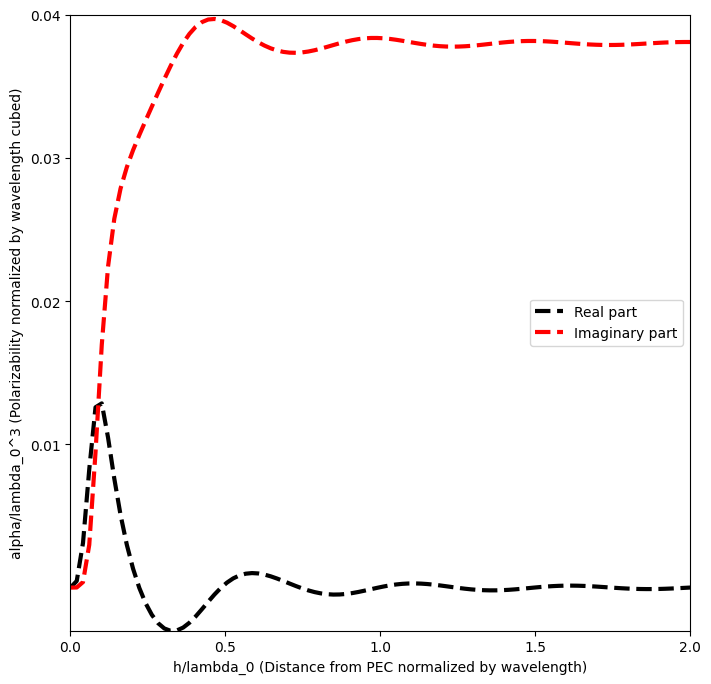

In [19]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(h_lambdas, alphas_real, color="black", linestyle="dashed", linewidth=3, label="Real part")
ax.plot(h_lambdas, alphas_imag, color="red", linestyle="dashed", linewidth=3, label="Imaginary part")
ax.set_xlim(0, 2)
ax.set_ylim(-0.003, 0.04);
ax.set_xlabel("h/lambda_0 (Distance from PEC normalized by wavelength)")
ax.set_ylabel("alpha/lambda_0^3 (Polarizability normalized by wavelength cubed)");
ax.set_yticks([0.01, 0.02, 0.03, 0.04])
ax.set_xticks(linspace(0, 2, 5));
ax.legend();

In [5]:
print("Maximum of real alpha: ", alphas_real.max())
print("Maximum of imaginary alpha: ", alphas_imag.max())

Maximum of real alpha:  0.01286079363101486
Maximum of imaginary alpha:  0.03969396276952244


### Now we try to find the conductivity. We do this by noting that $\alpha=-3\pi i/(\omega/c)^3\times(s-1)$

In [6]:
N = 1000
epsilon = 2 + 0.0j
alphas_real_from_s = zeros(N)
x_arr = linspace(0.1, 0.3, N)
for (x_idx, x) in enumerate(x_arr):
    s = e_r_cpa(1, x, epsilon)
    alpha_omega = -1j*(3*pi)*(s-1)/x**3
    alphas_real_from_s[x_idx] = alpha_omega.real

Text(0.5, 1.0, 'Comparison of quasistatic and fully retarded polarizabilities')

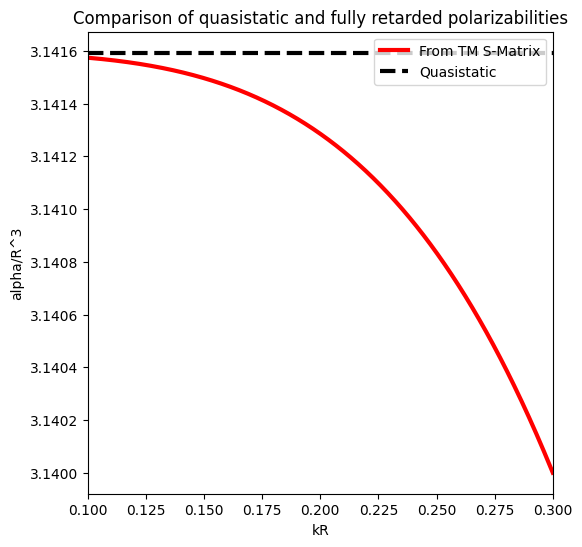

In [7]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(x_arr, alphas_real_from_s, label="From TM S-Matrix", color="red", linewidth=3)
ax.hlines([4*pi*(epsilon-1)/(epsilon+2)], x_arr.min(), x_arr.max(), linestyle="dashed", label="Quasistatic", color="black", linewidth=3)
ax.legend()
ax.set_xlabel("kR")
ax.set_ylabel("alpha/R^3")
ax.set_xlim(0.1, 0.3);
ax.set_title("Comparison of quasistatic and fully retarded polarizabilities")

### We now try to re-create Figure 3(b)

In [8]:
N = 1000
epsilon_real_v = linspace(-2.4, -2.1, N)
epsilon_imag_v = linspace(0, 0.14, N)
epsilon_arr = epsilon_real_v.reshape((N, 1)).repeat(N, axis=1) + 1j*epsilon_imag_v.reshape((1, N)).repeat(N, axis=0)

In [9]:
l = 1
x = 0.05*2*pi # R/lambda = 0.05 --> Rq = 2*pi*R/lambda
s_arr = e_r_cpa(l, x, epsilon_arr)
alpha_from_s_arr = (-3j*pi/(2*pi)**3)*(s_arr-1)

h = 2*pi/4
integrand_1 = quad(lambda k_p: alpha_integrand_1(k_p, h), 0, 1, limit=limit)[0]
integrand_2 = quad(lambda k_p: alpha_integrand_2(k_p, h), 0, 1-1e-10, limit=limit)[0]
integrand_3 = quad(lambda k_p: alpha_integrand_3(k_p, h), 0, 1, limit=limit)[0]
integrand_4 = quad(lambda k_p: alpha_integrand_4(k_p, h), 1, 100, limit=limit)[0]

alpha_analytic = 1j/(2*pi**2)*1/(integrand_1-integrand_2-1j*integrand_3+1j*integrand_4)

In [10]:
min_idx = (np.abs(alpha_from_s_arr - alpha_analytic)).argmin()
print("Epsilon corresponding to CPA: ", epsilon_arr.flatten()[min_idx].round(4))

Epsilon corresponding to CPA:  (-2.2357+0.0922j)


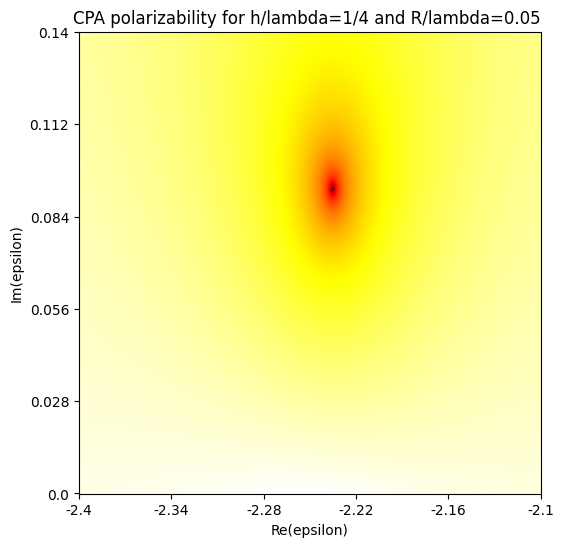

In [11]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(log(np.abs(alpha_from_s_arr - alpha_analytic)).T, cmap="hot", origin="lower")
ax.set_xticks(linspace(0, 999, 6), epsilon_real_v[linspace(0, 999, 6, dtype=int)].round(3));
ax.set_yticks(linspace(0, 999, 6), epsilon_imag_v[linspace(0, 999, 6, dtype=int)].round(3));
ax.set_xlabel("Re(epsilon)")
ax.set_ylabel("Im(epsilon)");
ax.set_title("CPA polarizability for h/lambda=1/4 and R/lambda=0.05 ");

### Now we note that $s=1+\frac{8\pi^2 i}{3}\tilde{\alpha}$, where $\tilde{\alpha}\equiv \alpha/\lambda_0^3$ and we calculate the surface conductivity required to achieve CPA at each value of $h/\lambda_0$

In [25]:
alpha_omega = alphas_real + 1j*alphas_imag
s = 1 + (8*pi**2*1j/3)*alpha_omega
l = 1
epsilon = 2.1 # Permittivity of the sphere
x = 0.5
M = 1000
m = sqrt(epsilon) # Refractive index
y = x * m # epsilonkR in the cylinder

j_ly = spherical_jn(l, y)
j_lx = spherical_jn(l, x)
y_lx = spherical_yn(l, x)

yjl_prime = spherical_jn(l, y) + y*spherical_jn(l, y, derivative=True)
xjl_prime = spherical_jn(l, x) + x*spherical_jn(l, x, derivative=True)
xyl_prime = spherical_yn(l, x) + x*spherical_yn(l, x, derivative=True)

g_prefac = -yjl_prime * ((xjl_prime + 1j* xyl_prime)*s + (xjl_prime - 1j* xyl_prime))
rhs_1 = epsilon*j_ly*((xjl_prime + 1j* xyl_prime)*s + (xjl_prime - 1j* xyl_prime))
rhs_2 = - yjl_prime * ((j_lx + 1j*y_lx)*s + (j_lx-1j*y_lx))
g = (rhs_1+rhs_2)/g_prefac
sigma = -1j*g*x
sigma_imaginary = sigma.imag
sigma_real = sigma.real
assert np.abs(e_r_cpa(l, x, epsilon, 1j*sigma/x)-s).max() < 1e-8 # Check the solution for sigma

### Note that we fix $x=kR$ in the above. Obviously, we require $h/\lambda_0>R/\lambda_0=kR/2\pi$, which sets the lower bound of our plots below

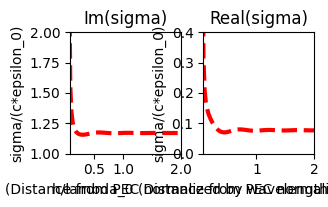

In [49]:
cm = 1/2.54
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8*cm, 4*cm))
ax1.plot(h_lambdas, sigma_imaginary, linestyle="dashed", linewidth=3, color="red")
ax1.set_xlim(x/(2*pi), 2)
ax1.set_ylim(1, 2)
ax1.set_xticks([0.5, 1, 2])

ax2.plot(h_lambdas, sigma_real, linestyle="dashed", linewidth=3, color="red")
ax2.set_xlim(x/(2*pi), 2)
ax1.set_xticks([0.5, 1, 2])
ax2.set_ylim(0, 0.4);
ax2.set_title("Real(sigma)")
ax1.set_title("Im(sigma)");
ax1.set_ylabel("sigma/(c*epsilon_0)")
ax2.set_ylabel("sigma/(c*epsilon_0)")
ax1.set_xlabel("h/lambda_0 (Distance from PEC normalized by wavelength)")
ax2.set_xlabel("h/lambda_0 (Distance from PEC normalized by wavelength)");
plt.savefig("./paper/scatterer_over_pec_1.pdf")

In [30]:
E_F = (hbar/tau)*(sigma_real**2+sigma_imaginary**2)/(4*sigma_real)/alpha;
a = c*tau*x*sigma_real/sigma_imaginary;
hbar_omega = hbar*(sigma_imaginary/sigma_real)*(1/tau)

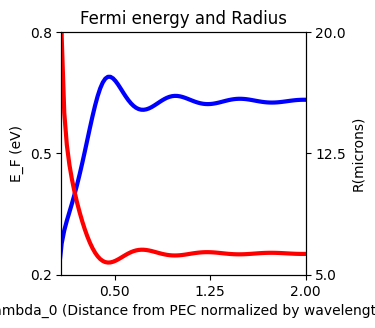

In [48]:
cm = 1/2.54
fig, (ax1) = plt.subplots(1, 1, figsize=(8*cm, 8*cm))
ax1.plot(h_lambdas, E_F, color="blue", linewidth=3)
ax1.set_xlim(x/(2*pi), 2)
ax1.set_ylim(0.2, 0.8);
ax1.set_yticks(linspace(0.2, 0.8, 3))
ax1.set_xticks(linspace(0.5, 2, 3))
ax1.set_ylabel("E_F (eV)")
ax1.set_xlabel("h/lambda_0 (Distance from PEC normalized by wavelength)");
ax1.set_title("Fermi energy and Radius")

ax2 = ax1.twinx()

ax2.plot(h_lambdas, a/1000, color="red", linewidth=3)
ax2.set_xlim(x/(2*pi), 2)
ax2.set_xticks(linspace(0.5, 2, 3))

ax2.set_ylim(5, 20);
ax2.set_yticks(linspace(5, 20, 3))
ax2.set_ylabel("R(microns)")
ax2.set_xlabel("h/lambda_0 (Distance from PEC normalized by wavelength)");
#ax2.set_title("Radius")

#ax3.plot(h_lambdas, (hbar_omega/hbar)*1e-12, color="black", linewidth=3)
#ax3.set_xlim(x/(2*pi), 2)
#ax3.set_yticks(linspace(0, 30, 3))
#ax3.set_xticks(linspace(0.5, 2, 3))
#ax3.set_ylim(0, 30);
#ax3.set_ylabel("omega (THz)")
#ax3.set_xlabel("h/lambda_0 (Distance from PEC normalized by wavelength)");
#ax3.set_title("Frequency");
plt.savefig("./paper/scatterer_over_pec.pdf")